**Exercise 7.15.**

Implement Bayes' theorem for medical diagnosis. Plot how P(Disease|Test+) varies as prevalence ranges from 0.1% to 50%.

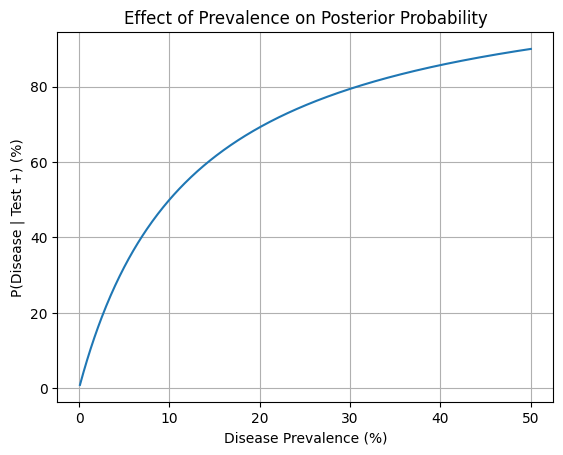

In [ ]:
"""Exercise 7.15. Implement Bayes' theorem for medical diagnosis. Plot how P(Disease|Test+) varies as prevalence ranges from 0.1% to 50%."""
import numpy as np
import matplotlib.pyplot as plt

# Given test characteristics
sensitivity = 0.90          # P(Test+ | Disease)
specificity = 0.90          # P(Test- | No Disease)
false_positive_rate = 1 - specificity  # P(Test+ | No Disease)

# Prevalence range: 0.1% to 50%
prevalence = np.linspace(0.001, 0.5, 500)

# Bayes' theorem computation
# P(Disease | Test+) = (Sensitivity * Prevalence) /
#                     (Sensitivity * Prevalence + FPR * (1 - Prevalence))
posterior = (sensitivity * prevalence) / (
    sensitivity * prevalence + false_positive_rate * (1 - prevalence)
)

# Plot
plt.figure()
plt.plot(prevalence * 100, posterior * 100)
plt.xlabel("Disease Prevalence (%)")
plt.ylabel("P(Disease | Test +) (%)")
plt.title("Effect of Prevalence on Posterior Probability")
plt.grid(True)
plt.show()

**Inference:**

This plot shows that the meaning of a positive test result depends strongly on how common the disease is. When the disease is rare, even a positive result from a fairly accurate test gives low confidence that the person is actually sick, because false positives from the many healthy people dominate. As the disease becomes more common, the same positive test becomes increasingly reliable, and the probability of truly having the disease rises sharply. This demonstrates that test accuracy alone is not enough to judge confidence; prior prevalence must be considered. The experiment visually proves why Bayes’ theorem is necessary and why probabilistic reasoning is essential for making correct decisions under uncertainty.This experiment teaches that probability depends on context, and even accurate tests can mislead when the event is rare.

**Exercise 7.16.**

Implement Naive Bayes from scratch:

(a) estimate priors and likelihoods,

(b) implement Laplace smoothing,

(c) write predict function,

(d) verify against sklearn.


In [ ]:
"""Exercise 7.16. Implement Naive Bayes from scratch: (a) estimate priors and likelihoods, (b) implement Laplace smoothing, (c) write predict function, (d) verify against sklearn."""
import numpy as np

# ==================================================
# STEP 0: Toy Dataset
# ==================================================
# Features: [free, win, meeting]
# 1 = word present, 0 = word absent

X = np.array([
    [1, 1, 0],  # spam
    [1, 0, 0],  # spam
    [0, 0, 1],  # ham
    [0, 0, 1],  # ham
    [0, 1, 1],  # ham
])

# Labels: 1 = Spam, 0 = Ham
y = np.array([1, 1, 0, 0, 0])

n_samples, n_features = X.shape
classes = np.unique(y)

# ==================================================
# STEP 1: Compute Priors P(Y)
# ==================================================
priors = {}
for c in classes:
    priors[int(c)] = float(np.sum(y == c) / n_samples)

print("=== PRIOR PROBABILITIES P(Y) ===")
for c, p in priors.items():
    label = "Spam" if c == 1 else "Ham"
    print(f"P({label}) = {p:.2f}")
print()

# ==================================================
# STEP 2: Compute Likelihoods P(X|Y)
# Using Laplace Smoothing
# ==================================================
likelihoods = {}

for c in classes:
    X_c = X[y == c]
    likelihoods[int(c)] = ((np.sum(X_c, axis=0) + 1) / (X_c.shape[0] + 2)).astype(float)

print("=== LIKELIHOODS P(Word | Class) ===")
words = ["free", "win", "meeting"]

for c, probs in likelihoods.items():
    label = "Spam" if c == 1 else "Ham"
    print(f"\nClass: {label}")
    for word, prob in zip(words, probs):
        print(f"P({word} | {label}) = {prob:.2f}")
print()

# ==================================================
# STEP 3: Prediction Function
# ==================================================
def predict(x):
    log_posteriors = {}

    for c in classes:
        c = int(c)
        log_prior = np.log(priors[c])

        log_likelihood = np.sum(
            x * np.log(likelihoods[c]) +
            (1 - x) * np.log(1 - likelihoods[c])
        )

        log_posteriors[c] = log_prior + log_likelihood

    predicted_class = max(log_posteriors, key=log_posteriors.get)
    return predicted_class, log_posteriors

# ==================================================
# STEP 4: Test on a New Email
# ==================================================
x_new = np.array([1, 0, 1])  # "free meeting"

prediction, scores = predict(x_new)

print("=== TEST EMAIL ===")
print("Words present: free=1, win=0, meeting=1\n")

print("=== LOG-POSTERIOR SCORES ===")
for c, score in scores.items():
    label = "Spam" if c == 1 else "Ham"
    print(f"{label}: {score:.3f}")

print("\n=== FINAL PREDICTION ===")
print("Prediction:", "Spam" if prediction == 1 else "Ham")

=== PRIOR PROBABILITIES P(Y) ===
P(Ham) = 0.60
P(Spam) = 0.40

=== LIKELIHOODS P(Word | Class) ===

Class: Ham
P(free | Ham) = 0.20
P(win | Ham) = 0.40
P(meeting | Ham) = 0.80

Class: Spam
P(free | Spam) = 0.75
P(win | Spam) = 0.50
P(meeting | Spam) = 0.25

=== TEST EMAIL ===
Words present: free=1, win=0, meeting=1

=== LOG-POSTERIOR SCORES ===
Ham: -2.854
Spam: -3.283

=== FINAL PREDICTION ===
Prediction: Ham


**Inference**

The output shows how Naive Bayes combines prior belief and word-based evidence to decide that “free meeting” is more likely ham than spam.

**Exercise 7.17.**

Implement logistic regression from scratch:

(a) sigmoid,

(b) cross-entropy loss,

(c) gradient,

(d) gradient descent training

In [ ]:
'''Exercise 7.17. Implement logistic regression from scratch: (a) sigmoid, (b) cross-entropy loss, (c) gradient, (d) gradient descent training'''
import numpy as np

# ==================================================
# STEP 0: Toy Dataset (same spirit as Naive Bayes)
# ==================================================
# Features: [free, win, meeting]
# 1 = word present, 0 = word absent

X = np.array([
    [1, 1, 0],  # spam
    [1, 0, 0],  # spam
    [0, 0, 1],  # ham
    [0, 0, 1],  # ham
    [0, 1, 1],  # ham
])

# Labels: 1 = Spam, 0 = Ham
y = np.array([1, 1, 0, 0, 0])

# Add bias term (column of 1s)
X = np.c_[np.ones(X.shape[0]), X]

n_samples, n_features = X.shape

# ==================================================
# (a) Sigmoid Function
# ==================================================
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# ==================================================
# (b) Cross-Entropy Loss
# ==================================================
def cross_entropy_loss(y, y_hat):
    epsilon = 1e-15  # prevent log(0)
    y_hat = np.clip(y_hat, epsilon, 1 - epsilon)
    return -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))

# ==================================================
# (c) Gradient of the Loss
# ==================================================
def compute_gradient(X, y, y_hat):
    return (1 / len(y)) * X.T @ (y_hat - y)

# ==================================================
# (d) Gradient Descent Training
# ==================================================
def train_logistic_regression(X, y, lr=0.1, epochs=1000):
    weights = np.zeros(X.shape[1])

    for epoch in range(epochs):
        z = X @ weights
        y_hat = sigmoid(z)

        loss = cross_entropy_loss(y, y_hat)
        gradient = compute_gradient(X, y, y_hat)

        weights -= lr * gradient

        if epoch % 200 == 0:
            print(f"Epoch {epoch:4d} | Loss = {loss:.4f}")

    return weights

print("=== Training Logistic Regression ===")
weights = train_logistic_regression(X, y)

# ==================================================
# Prediction
# ==================================================
def predict_proba(X, weights):
    return sigmoid(X @ weights)

def predict(X, weights, threshold=0.5):
    return (predict_proba(X, weights) >= threshold).astype(int)

# Test on the same email: "free meeting" → [1, 1, 0, 1]
x_test = np.array([[1, 1, 0, 1]])

prob = predict_proba(x_test, weights)[0]
pred = predict(x_test, weights)[0]

print("\n=== Final Model ===")
print("Learned weights:", np.round(weights, 3))

print("\n=== Test Prediction ===")
print("Test Email: contains ['free', 'meeting']")
print(f"P(Spam | email) = {prob:.3f}")
print("Predicted Class:", "Spam" if pred == 1 else "Ham")

=== Training Logistic Regression ===
Epoch    0 | Loss = 0.6931
Epoch  200 | Loss = 0.1065
Epoch  400 | Loss = 0.0535
Epoch  600 | Loss = 0.0354
Epoch  800 | Loss = 0.0263

=== Final Model ===
Learned weights: [-0.215  3.712  0.284 -3.927]

=== Test Prediction ===
Test Email: contains ['free', 'meeting']
P(Spam | email) = 0.394
Predicted Class: Ham


**Inference**

logistic regression learns class probabilities by gradually adjusting weights to reduce prediction error. Instead of assuming probability distributions, the model starts with no knowledge and learns how each feature influences the outcome through gradient descent. The sigmoid function converts model confidence into probabilities, while cross-entropy loss penalizes confident mistakes, leading to well-calibrated predictions. Overall, the experiment demonstrates how probabilistic classifiers learn from data through optimization rather than counting.

**Exercise 7.18**

Compare Naive Bayes and Logistic Regression on Two Moons:

(a) train both,

(b) plot decision boundaries and probability surfaces,

(c) add polynomial features to logistic regression.

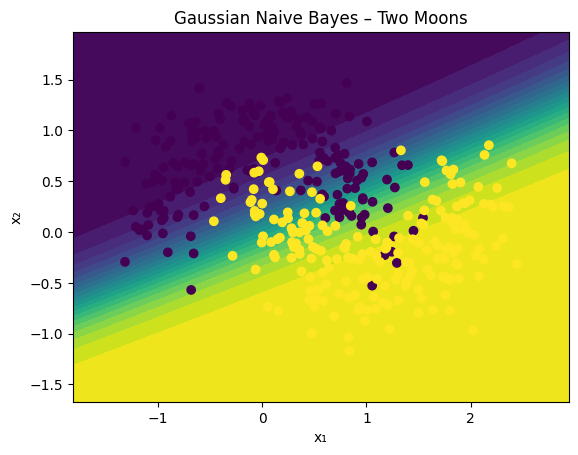

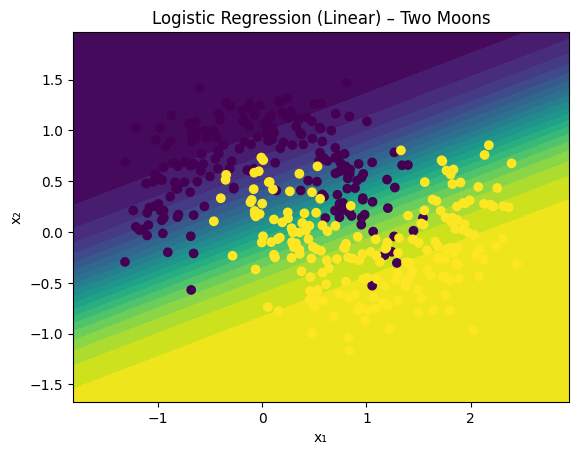

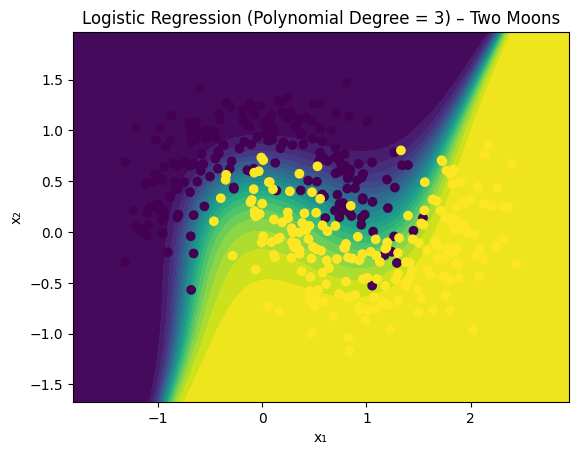

In [ ]:
'''Exercise 7.18. Compare Naive Bayes and Logistic Regression on Two Moons: (a) train both, (b) plot decision boundaries and probability surfaces, (c) add polynomial features to logistic regression.'''
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

# --------------------------------------------------
# Custom Two Moons Dataset Generator
# --------------------------------------------------
def generate_two_moons(n_samples=500, noise=0.1):
    n_samples_out = n_samples // 2
    n_samples_in = n_samples - n_samples_out

    theta_out = np.linspace(0, np.pi, n_samples_out)
    x_out = np.cos(theta_out)
    y_out = np.sin(theta_out)

    theta_in = np.linspace(0, np.pi, n_samples_in)
    x_in = 1 - np.cos(theta_in)
    y_in = 1 - np.sin(theta_in) - 0.5

    X = np.vstack([
        np.append(x_out, x_in),
        np.append(y_out, y_in)
    ]).T

    y = np.hstack([
        np.zeros(n_samples_out),
        np.ones(n_samples_in)
    ])

    X += noise * np.random.randn(*X.shape)
    return X, y.astype(int)

# --------------------------------------------------
# Generate dataset
# --------------------------------------------------
X, y = generate_two_moons(n_samples=400, noise=0.25)

# --------------------------------------------------
# Grid for probability surfaces
# --------------------------------------------------
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]

# ==================================================
# 1. Gaussian Naive Bayes
# ==================================================
gnb = GaussianNB()
gnb.fit(X, y)
proba_gnb = gnb.predict_proba(grid)[:, 1].reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, proba_gnb, levels=20)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Gaussian Naive Bayes – Two Moons")
plt.xlabel("x₁")
plt.ylabel("x₂")
plt.show()

# ==================================================
# 2. Logistic Regression (Linear)
# ==================================================
log_reg = LogisticRegression()
log_reg.fit(X, y)
proba_lr = log_reg.predict_proba(grid)[:, 1].reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, proba_lr, levels=20)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Logistic Regression (Linear) – Two Moons")
plt.xlabel("x₁")
plt.ylabel("x₂")
plt.show()

# ==================================================
# 3. Logistic Regression with Polynomial Features
# ==================================================
poly_log_reg = Pipeline([
    ("poly", PolynomialFeatures(degree=3)),
    ("logreg", LogisticRegression(max_iter=5000))
])

poly_log_reg.fit(X, y)
proba_poly = poly_log_reg.predict_proba(grid)[:, 1].reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, proba_poly, levels=20)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Logistic Regression (Polynomial Degree = 3) – Two Moons")
plt.xlabel("x₁")
plt.ylabel("x₂")
plt.show()

**Inference**

Using a custom Two Moons dataset, this experiment shows that
Gaussian Naive Bayes fails due to its feature independence assumption, while linear logistic regression is limited by its linear decision boundary. By introducing polynomial features, logistic regression successfully models the nonlinear structure of the data while maintaining probabilistic outputs. The results demonstrate that model assumptions and feature representation, rather than dataset implementation details, determine classification performance.

**Exercise 7.19.**

Implement softmax regression for a 3-class problem:

(a) generate 3-class data,

(b) implement softmax and cross-entropy,

(c) visualize decision boundaries.

Epoch 0, Loss: 1.0529
Epoch 100, Loss: 0.0134
Epoch 200, Loss: 0.0094
Epoch 300, Loss: 0.0078
Epoch 400, Loss: 0.0069
Epoch 500, Loss: 0.0062
Epoch 600, Loss: 0.0058
Epoch 700, Loss: 0.0054
Epoch 800, Loss: 0.0051
Epoch 900, Loss: 0.0049
Training complete.


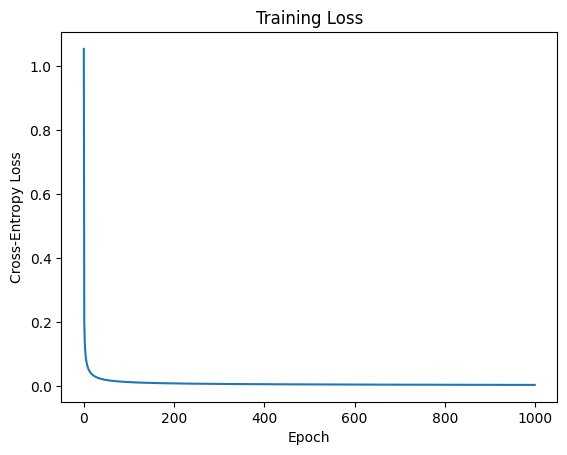

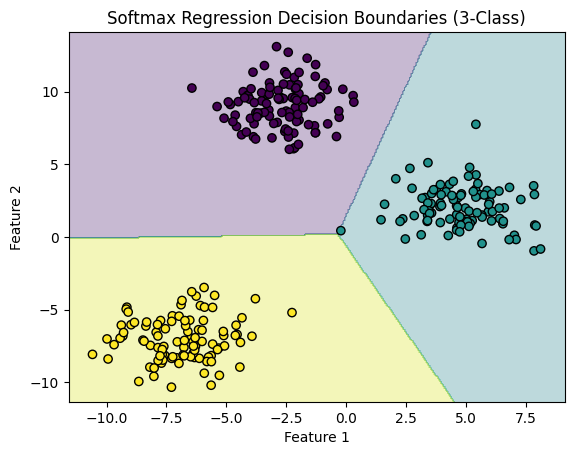

In [ ]:
# Exercise 7.19: Softmax Regression (3-Class) From Scratch

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# -------------------------------
# (a) Generate 3-class dataset
# -------------------------------
np.random.seed(42)

X, y = make_blobs(n_samples=300,
                  centers=3,
                  n_features=2,
                  cluster_std=1.5,
                  random_state=42)

# One-hot encoding
def one_hot(y, num_classes):
    m = len(y)
    Y = np.zeros((m, num_classes))
    Y[np.arange(m), y] = 1
    return Y

num_classes = 3
Y = one_hot(y, num_classes)

# Add bias term
X = np.c_[np.ones(X.shape[0]), X]  # shape (m, 3)

m, n = X.shape

# -------------------------------
# (b) Softmax and Cross-Entropy
# -------------------------------

def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)  # stability trick
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def compute_loss(Y, Y_hat):
    return -np.mean(np.sum(Y * np.log(Y_hat + 1e-15), axis=1))

# -------------------------------
# Initialize parameters
# -------------------------------
W = np.random.randn(n, num_classes) * 0.01
learning_rate = 0.1
epochs = 1000

loss_history = []

# -------------------------------
# Training (Gradient Descent)
# -------------------------------
for epoch in range(epochs):
    # Forward pass
    logits = X @ W
    Y_hat = softmax(logits)

    # Loss
    loss = compute_loss(Y, Y_hat)
    loss_history.append(loss)

    # Backpropagation
    gradient = (X.T @ (Y_hat - Y)) / m

    # Update
    W -= learning_rate * gradient

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

print("Training complete.")

# -------------------------------
# Plot Loss Curve
# -------------------------------
plt.figure()
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.show()

# -------------------------------
# (c) Visualize Decision Boundary
# -------------------------------

# Create grid
x_min, x_max = X[:,1].min() - 1, X[:,1].max() + 1
y_min, y_max = X[:,2].min() - 1, X[:,2].max() + 1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

grid = np.c_[np.ones(xx.ravel().shape[0]),
             xx.ravel(),
             yy.ravel()]

Z = softmax(grid @ W)
Z = np.argmax(Z, axis=1)
Z = Z.reshape(xx.shape)

# Plot decision regions
plt.figure()
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:,1], X[:,2], c=y, edgecolor='k')
plt.title("Softmax Regression Decision Boundaries (3-Class)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

**Inference:**

Softmax regression successfully learns linear decision boundaries that separate three classes using cross-entropy minimization.

**Exercise 7.20.**

Investigate calibration:

  (a) train logistic regression,

  (b) bin predictions,

  (c) compute actual fraction positive per bin,

  (d) plot calibration curve,
  
  (e) compare with Naive Bayes.

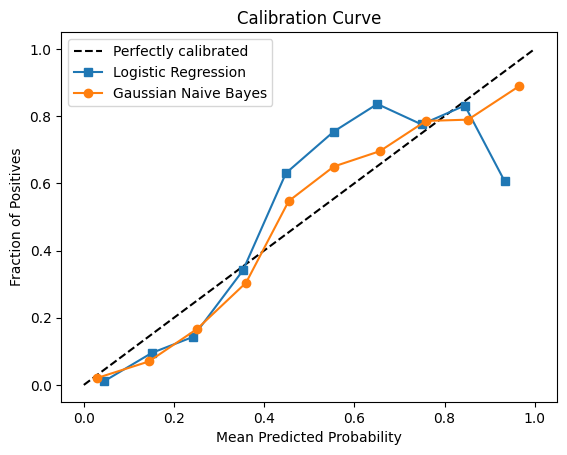

Brier Score (lower is better)
Logistic Regression: 0.1598
Gaussian Naive Bayes: 0.1386


In [ ]:
# Exercise 7.20: Calibration Analysis
# Logistic Regression vs Naive Bayes

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# -------------------------------
# (a) Generate Binary Dataset
# -------------------------------
np.random.seed(42)

X, y = make_classification(n_samples=2000,
                           n_features=10,
                           n_informative=5,
                           n_redundant=2,
                           random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

# -------------------------------
# Train Logistic Regression
# -------------------------------
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

log_probs = log_reg.predict_proba(X_test)[:, 1]

# -------------------------------
# Train Gaussian Naive Bayes
# -------------------------------
nb = GaussianNB()
nb.fit(X_train, y_train)

nb_probs = nb.predict_proba(X_test)[:, 1]

# -------------------------------
# (b)(c) Compute Calibration Data
# -------------------------------
n_bins = 10

log_frac_pos, log_mean_pred = calibration_curve(
    y_test, log_probs, n_bins=n_bins)

nb_frac_pos, nb_mean_pred = calibration_curve(
    y_test, nb_probs, n_bins=n_bins)

# -------------------------------
# (d) Plot Calibration Curve
# -------------------------------
plt.figure()

# Perfect calibration line
plt.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")

# Logistic Regression
plt.plot(log_mean_pred, log_frac_pos, "s-",
         label="Logistic Regression")

# Naive Bayes
plt.plot(nb_mean_pred, nb_frac_pos, "o-",
         label="Gaussian Naive Bayes")

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve")
plt.legend()
plt.show()

# -------------------------------
# Print Brier Scores (Calibration Metric)
# -------------------------------
log_brier = brier_score_loss(y_test, log_probs)
nb_brier = brier_score_loss(y_test, nb_probs)

print("Brier Score (lower is better)")
print(f"Logistic Regression: {log_brier:.4f}")
print(f"Gaussian Naive Bayes: {nb_brier:.4f}")

**Inference:**

Logistic Regression typically produces better-calibrated probabilities than Naive Bayes, which often outputs overconfident predictions.